# **Big Data Handling Strategies: Assignment Notebook**

**SECP3133 High Performance Data Processing**  
Semester 2 2025/2026  
Section 01  
**Lecturer**: Assoc. Prof. Dr. Mohd Shahizan Bin Othman  
**Group Name**: Horang

Students:
* Goe Jie Ying A23CS0224
* Lam Yoke Yu A23CS0233

## **Task 1: Dataset Selection**
**Dataset**: [Genius Song Lyrics](https://www.kaggle.com/datasets/carlosgdcj/genius-song-lyrics-with-language-information/data)  
**Source**: Kaggle  
**Data Size**: 9.07 GB


## **Task 2: Load and Inspect Data**

In [1]:
!pip install polars dask pyarrow kaggle

In [2]:
import os
import re

import pandas as pd
import numpy as np
import pyarrow
import pyarrow.csv as pv_csv
import polars as pl
import dask.dataframe as dd

import matplotlib.pyplot as plt
import seaborn as sns

import tracemalloc
import time

In [3]:
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('kusername')
os.environ['KAGGLE_KEY'] = userdata.get('kkey')

In [ ]:
# from google.colab import files
# files.upload()

# os.makedirs('/root/.kaggle', exist_ok=True)
# os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
# os.chmod('/root/.kaggle/kaggle.json', 600)

In [4]:
!kaggle datasets download -d carlosgdcj/genius-song-lyrics-with-language-information

Dataset URL: https://www.kaggle.com/datasets/carlosgdcj/genius-song-lyrics-with-language-information
License(s): unknown
100% 3.04G/3.04G [01:23<00:00, 38.9MB/s]



In [5]:
!unzip genius-song-lyrics-with-language-information.zip

Archive:  genius-song-lyrics-with-language-information.zip
  inflating: song_lyrics.csv         


The dataset from Kaggle was loaded and its data types were inspected. To avoid a kernel crash, only 1,000,000 rows were loaded for inspection.

In [6]:
# Load a portion of data for inspection purpose
df = pd.read_csv(
   'song_lyrics.csv',
   nrows=1000000
)

In [7]:
# Inspect the first 5 rows of the data
df.head(5)

,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language
0,Killa Cam,rap,Cam'ron,2004,173166,"{""Cam\\'ron"",""Opera Steve""}","[Chorus: Opera Steve & Cam'ron]\nKilla Cam, Ki...",1,en,en,en
1,Can I Live,rap,JAY-Z,1996,468624,{},"[Produced by Irv Gotti]\n\n[Intro]\nYeah, hah,...",3,en,en,en
2,Forgive Me Father,rap,Fabolous,2003,4743,{},Maybe cause I'm eatin\nAnd these bastards fien...,4,en,en,en
3,Down and Out,rap,Cam'ron,2004,144404,"{""Cam\\'ron"",""Kanye West"",""Syleena Johnson""}",[Produced by Kanye West and Brian Miller]\n\n[...,5,en,en,en
4,Fly In,rap,Lil Wayne,2005,78271,{},"[Intro]\nSo they ask me\n""Young boy\nWhat you ...",6,en,en,en


In [8]:
print(f"\nDataset Shape:\nRows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\nColumn Names and Data Types:")
print(df.dtypes)

print("\nSummary Info:")
df.info()


Dataset Shape:
Rows: 1000000, Columns: 11

Column Names and Data Types:
title            object
tag              object
artist           object
year              int64
views             int64
features         object
lyrics           object
id                int64
language_cld3    object
language_ft      object
language         object
dtype: object

Summary Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   title          999984 non-null   object
 1   tag            1000000 non-null  object
 2   artist         1000000 non-null  object
 3   year           1000000 non-null  int64 
 4   views          1000000 non-null  int64 
 5   features       1000000 non-null  object
 6   lyrics         1000000 non-null  object
 7   id             1000000 non-null  int64 
 8   language_cld3  990143 non-null   object
 9   language_ft    985372 

In [9]:
df.nunique()

,0
title,705798
tag,6
artist,106435
year,456
views,48495
features,64829
lyrics,985806
id,1000000
language_cld3,96
language_ft,84


From the inspection, it was observed that the dataset has 11 columns.

The `years`, `views` and `id` columns are numerical, while `tag`, `language_cld3`, `language_ft` and `language` are categorical, given their low ratio of unique values relative to the total number of rows.

### Load, clean and save data
The data was cleaned and the `on_bad_lines` parameter was used to skip problematic rows to ensure that PyArrow and Dask run smoothly, as both may fail when encountering corrupted data.

Chunking was implemented when loading the full dataset to prevent the session from crashing.

The cleaned data was saved as `song_lyrics_clean.csv` for further use. To ensure fair comparison, all implemented strategies use the cleaned data.

The `lyrics` column is dropped to ensure that all strategies can be executed without exceeding the available RAM.

In [10]:
cols_without_lyrics = ['title', 'tag', 'artist', 'year', 'views', 'features', 'id', 'language_cld3', 'language_ft', 'language']

In [11]:
def parse_features(x):
    if x == "{}":
        return []

    # Remove { and }
    x = x.strip("{}")

    # Split on comma outside quotes
    items = re.findall(r'"(.*?)"', x)

    # Fix escaped characters
    items = [i.replace("\\'", "'").replace("\\\\", "\\") for i in items]

    return items

In [12]:
def load_clean(output_path="song_lyrics_clean.csv"):
    if os.path.exists(output_path):
        return

    for i, chunk in enumerate(pd.read_csv(
        "song_lyrics.csv",
        engine="python",
        usecols=cols_without_lyrics,      # comment for csv with lyrics
        on_bad_lines="skip",
        chunksize=25_000
    )):
        # chunk = chunk.dropna(subset=["lyrics"])   # comment for csv without lyrics
        # chunk['lyrics'] = (
        #     chunk['lyrics']
        #     .astype(str)
        #     .str.replace('"', '', regex=False)
        #     .str.replace('\n', ' ', regex=False)
        #     .str.replace(',', '', regex=False)
        # )

        chunk['title'] = chunk['title'].fillna('Unknown')
        chunk['language_cld3'] = chunk['language_cld3'].fillna('Unknown')
        chunk['language_ft'] = chunk['language_ft'].fillna('Unknown')
        chunk['language'] = chunk['language'].fillna('Unknown')
        chunk["features"] = chunk["features"].apply(parse_features)

        chunk.to_csv(output_path, mode="a", header=(i == 0), index=False)

    return

load_clean()

In [13]:
# Validate the cleaned data
df = pd.read_csv(
   'song_lyrics_clean.csv',
   nrows=10
)
df

,title,tag,artist,year,views,features,id,language_cld3,language_ft,language
0,Killa Cam,rap,Cam'ron,2004,173166,"[""Cam\\'ron"", 'Opera Steve']",1,en,en,en
1,Can I Live,rap,JAY-Z,1996,468624,[],3,en,en,en
2,Forgive Me Father,rap,Fabolous,2003,4743,[],4,en,en,en
3,Down and Out,rap,Cam'ron,2004,144404,"[""Cam\\'ron"", 'Kanye West', 'Syleena Johnson']",5,en,en,en
4,Fly In,rap,Lil Wayne,2005,78271,[],6,en,en,en
5,Lollipop Remix,rap,Lil Wayne,2008,580832,"['Kanye West', 'Static Major']",7,en,en,en
6,Im Not You,rap,Clipse,2002,28645,"['Styles P', 'Roscoe P. Coldchain']",8,en,en,en
7,Family Ties,rap,Cam'ron,2004,41960,"[""Cam\\'ron"", 'Lady Wray']",9,en,en,en
8,Rockin and Rollin,rap,Cam'ron,1998,6399,"[""Cam\\'ron""]",10,en,en,en
9,Lord You Know,rap,Cam'ron,2004,11882,"[""Cam\\'ron"", 'Juelz Santana']",11,en,en,en


## Task 3: Big Data Handling Strategies
In this section, five strategies are applied to the dataset. These strategies include:

* Loading less data
* Chunking
* Data type optimisation
* Sampling
* Parallel processing with scalable libraries

A dictionary is created to store the performance of each strategy.

In addition, a `measure_performance` function is implemented to track performance metrics.


In [14]:
summary = {
    'Strategy': [],
    'Row Count': [],
    'Column Count': [],
    'Load Time (s)': [],
    'Peak Memory (MB)': [],
    'Memory Usage (MB)': [],
}

def get_memory_usage(df):
    if isinstance(df, pd.DataFrame):
        return df.memory_usage(deep=True).sum()

    elif isinstance(df, pl.DataFrame):
        return df.estimated_size()

    elif isinstance(df, pyarrow.Table):
        return df.nbytes

def measure_performance(read_func, strategy_name):
    tracemalloc.start()
    start = time.perf_counter()

    # Read the dataset
    df = read_func()
    # print(df[:5])

    load_time = time.perf_counter() - start
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    mem_usage = get_memory_usage(df)
    df_cleaned_len = df.shape[0]

    # Log the performance
    print(f"Strategy: {strategy_name}")
    print(f"Row Count: {df.shape[0]}")
    print(f"Column Count: {df.shape[1]}")
    print(f"Load Time: {load_time:.4f}s")
    print(f"Peak Memory: {peak / 1024 / 1024:.2f} MB")
    print(f"Memory Usage: {mem_usage / 1024**2:.2f} MB")

    summary['Strategy'].append(strategy_name)
    summary['Row Count'].append(df.shape[0])
    summary['Column Count'].append(df.shape[1])
    summary['Load Time (s)'].append(round(load_time, 4))
    summary['Peak Memory (MB)'].append(round(peak / 1024**2, 2))
    summary['Memory Usage (MB)'].append(round(mem_usage / 1024**2, 2))

### Benchmarking
Data loading without any optimisation was executed.

In [15]:
def read_pandas():
   return pd.read_csv('song_lyrics_clean.csv')

measure_performance(read_pandas, 'Pandas')

Strategy: Pandas
Row Count: 5134856
Column Count: 10
Load Time: 29.7292s
Peak Memory: 1842.56 MB
Memory Usage: 2033.14 MB


### Strategy 1: Load Less Data
This strategy loads only the specific columns or rows required for the analysis.

In this case, `title` and `id` were excluded as they are identifiers of individual records. Additionally, `language_cld3` and `language_ft` were removed, as `language` is derived from these two columns.

This approach is expected to reduce memory consumption and improve read performance.

In [16]:
def load_less_data():
    cols_needed = ['tag', 'artist', 'year', 'views', 'features', 'language']
    return pd.read_csv('song_lyrics_clean.csv', usecols=cols_needed)

measure_performance(load_less_data, 'Load Less Data')

Strategy: Load Less Data
Row Count: 5134856
Column Count: 6
Load Time: 12.8933s
Peak Memory: 909.30 MB
Memory Usage: 1159.92 MB


### Strategy 2: Chunking
This approach reads data in manageable chunks and then combines them.

Chunking is expected to reduce RAM usage.

In [17]:
def chunking():
    chunks = []

    for chunk in pd.read_csv('song_lyrics_clean.csv', chunksize=10000):
      chunk.columns = chunk.columns.str.strip()
      chunks.append(chunk)

    return pd.concat(chunks, ignore_index=True)

measure_performance(chunking, 'Chunks of 10000')

Strategy: Chunks of 10000
Row Count: 5134856
Column Count: 10
Load Time: 32.5280s
Peak Memory: 1242.31 MB
Memory Usage: 2033.14 MB


### Strategy 3: Optimise Data Types
This approach reduces memory usage by assigning more efficient data types to each column when loading the dataset.

Numeric columns, including `year`, `views` and `id` are stored using smaller integer types, while categorical or repetitive text fields, including `tag`, `artist` and `language` can be stored using more memory-efficient formats instead of generic strings.

It is expected to have a lower memory consumption and improved performance.

In [18]:
def optimise_data_types():
  return pd.read_csv('song_lyrics_clean.csv', dtype={
    "title": "string",
    "tag": "category",
    "artist": "category",
    "year": "Int16",
    "views": "Int64",
    "features": "string",
    # "lyrics": "string",
    "id": "Int64",
    'language_cld3': "category",
    'language_ft': "category",
    "language": "category"
  })

measure_performance(optimise_data_types, 'Optimise Data Types')

Strategy: Optimise Data Types
Row Count: 5134856
Column Count: 10
Load Time: 386.5331s
Peak Memory: 1298.81 MB
Memory Usage: 812.42 MB


### Strategy 4: Sampling
This approach reduces memory usage by loading only a subset of the dataset instead of the entire file.

In this implementation, 10% of the entire dataset is sampled.

In [19]:
def sampling():
  return pd.read_csv('song_lyrics_clean.csv', nrows=int(0.1 * 5134855))

measure_performance(sampling, 'Sampling')

Strategy: Sampling
Row Count: 513485
Column Count: 10
Load Time: 2.8531s
Peak Memory: 180.68 MB
Memory Usage: 202.69 MB


### Strategy 5: Parallel Processing
Parallel processing involves distributing a computational task across multiple
processor cores simultaneously.

For this section, parallel processing is implemented using different libraries includiing PyArrow, Polars and Dask.

#### Library: PyArrow

In [20]:
def read_pyarrow():
    parse_options = pv_csv.ParseOptions(delimiter=",", quote_char='"')
    read_options = pv_csv.ReadOptions()
    convert_options = pv_csv.ConvertOptions()

    table = pv_csv.read_csv(
        "song_lyrics_clean.csv",
        parse_options=parse_options,
        read_options=read_options,
        convert_options=convert_options
    )
    return table.to_pandas()

measure_performance(read_pyarrow, "PyArrow")

Strategy: PyArrow
Row Count: 5134856
Column Count: 10
Load Time: 12.8971s
Peak Memory: 522.00 MB
Memory Usage: 2033.14 MB


#### Library: Polars

In [21]:
def read_polars():
    return pl.read_csv('song_lyrics_clean.csv')

measure_performance(read_polars, "Polars")

Strategy: Polars
Row Count: 5134856
Column Count: 10
Load Time: 2.5957s
Peak Memory: 0.01 MB
Memory Usage: 329.05 MB


#### Library: Dask

In [22]:
def read_dask():
    df = dd.read_csv(
        "song_lyrics_clean.csv",
        engine="python",
        on_bad_lines="skip",
        blocksize="64MB",
        dtype=str
    )

    df = df.compute()

    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df['views'] = pd.to_numeric(df['views'], errors='coerce')
    df['id'] = pd.to_numeric(df['id'], errors='coerce')

    return df

measure_performance(read_dask, 'Dask')

Strategy: Dask
Row Count: 5134856
Column Count: 10
Load Time: 622.7926s
Peak Memory: 1721.42 MB
Memory Usage: 657.15 MB


## Task 4: Comparative Analysis
The analysis is divided into two parts. The first part compares different strategies using the `pandas` library. The second part compares the performance across different libraries.


In [23]:
summary_df = pd.DataFrame(summary)
summary_df

,Strategy,Row Count,Column Count,Load Time (s),Peak Memory (MB),Memory Usage (MB)
0,Pandas,5134856,10,29.7292,1842.56,2033.14
1,Load Less Data,5134856,6,12.8933,909.30,1159.92
2,Chunks of 10000,5134856,10,32.5280,1242.31,2033.14
3,Optimise Data Types,5134856,10,386.5331,1298.81,812.42
4,Sampling,513485,10,2.8531,180.68,202.69
5,PyArrow,5134856,10,12.8971,522.00,2033.14
6,Polars,5134856,10,2.5957,0.01,329.05
7,Dask,5134856,10,622.7926,1721.42,657.15


In [24]:
# Separate the collected data for strategies and libraries
libraries = ["Pandas", "PyArrow", "Polars", "Dask"]

libraries_df = summary_df[summary_df["Strategy"].isin(libraries)]

strategies_df = summary_df[
    (~summary_df["Strategy"].isin(libraries)) | (summary_df["Strategy"] == "Pandas")
]

In [25]:
def best_strategy(df):
  best_time_strategy = df.loc[df['Load Time (s)'].idxmin()]
  best_mem_strategy = df.loc[df['Memory Usage (MB)'].idxmin()]

  print("Comparative Analysis:")
  print(f"Best loading time: {best_time_strategy['Strategy']} with {best_time_strategy['Load Time (s)']} seconds")
  print(f"Best memory usage: {best_mem_strategy['Strategy']} with {best_mem_strategy['Memory Usage (MB)']} MB")

In [26]:
# Function for visualisation
def add_labels(ax, fmt):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt)

def visualisation(df, x_label):
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    ax0 = sns.barplot(x="Strategy", y='Load Time (s)', data=df, ax=axes[0], palette='viridis', hue="Strategy")
    axes[0].set_title('Load Time Comparison (s)')
    axes[0].set_ylabel('Load Time (s)')
    axes[0].set_xlabel(x_label)
    axes[0].tick_params(axis='x', rotation=45)
    add_labels(ax0, '%.3f')

    ax1 = sns.barplot(x="Strategy", y='Peak Memory (MB)', data=df, ax=axes[1], palette='viridis', hue="Strategy")
    axes[1].set_title('Peak Memory Comparison (MB)')
    axes[1].set_ylabel('Peak Memory (MB)')
    axes[1].set_xlabel(x_label)
    axes[1].tick_params(axis='x', rotation=45)
    add_labels(ax1, '%.2f')

    ax2 = sns.barplot(x="Strategy", y='Memory Usage (MB)', data=df, ax=axes[2], palette='viridis', hue="Strategy")
    axes[2].set_title('Memory Usage Comparison (MB)')
    axes[2].set_ylabel('Memory Usage (MB)')
    axes[2].set_xlabel(x_label)
    axes[2].tick_params(axis='x', rotation=45)
    add_labels(ax2, '%.2f')

    plt.tight_layout()
    plt.show()

### Comparison Between Different Strategies
The dataset and libraries are controlled to ensure consistency, while different data handling strategies are evaluated based on performance metrics.

In [27]:
best_strategy(strategies_df)

Comparative Analysis:
Best loading time: Sampling with 2.8531 seconds
Best memory usage: Sampling with 202.69 MB


In [28]:
strategies_df

,Strategy,Row Count,Column Count,Load Time (s),Peak Memory (MB),Memory Usage (MB)
0,Pandas,5134856,10,29.7292,1842.56,2033.14
1,Load Less Data,5134856,6,12.8933,909.30,1159.92
2,Chunks of 10000,5134856,10,32.5280,1242.31,2033.14
3,Optimise Data Types,5134856,10,386.5331,1298.81,812.42
4,Sampling,513485,10,2.8531,180.68,202.69


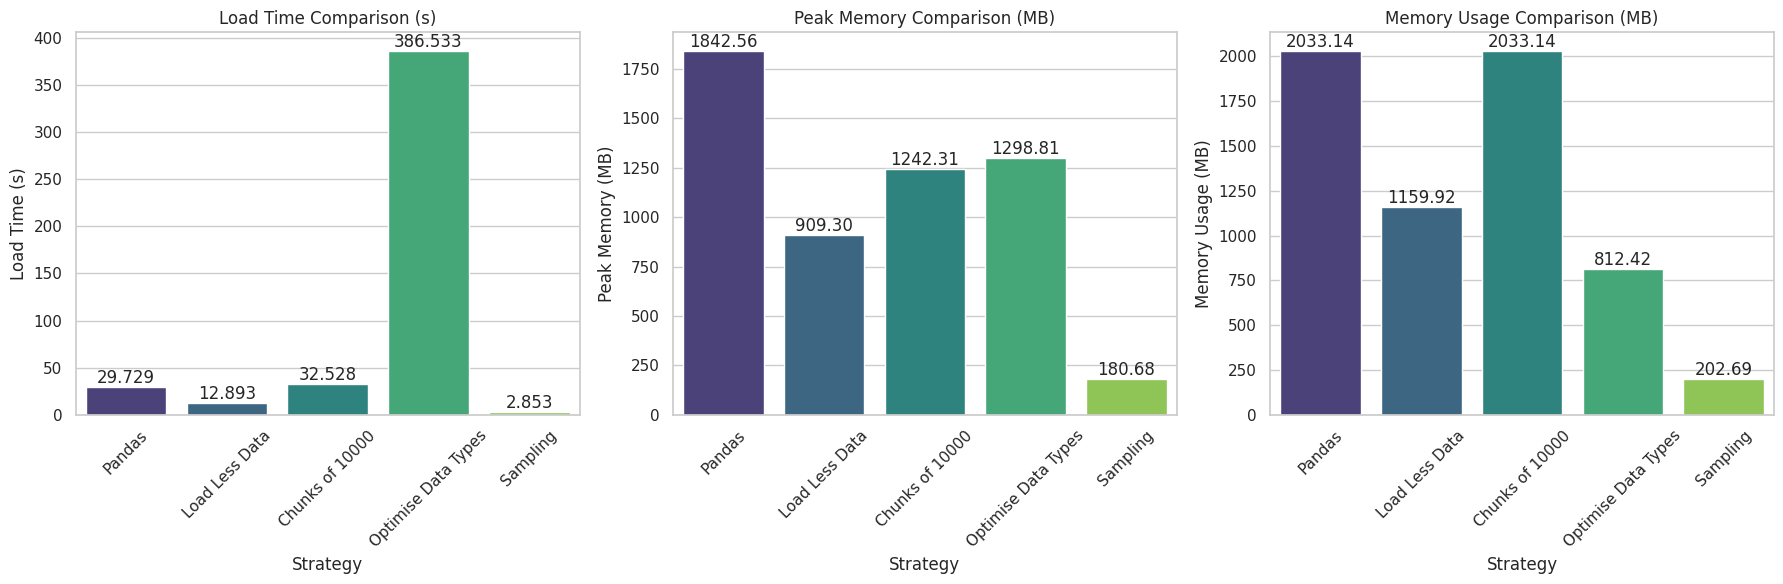

In [29]:
visualisation(strategies_df, 'Strategy')

According to the results, **sampling** yields the best performance, as it significantly reduces memory usage and load time due to the 90% reduction in data loaded. However, it substantially reduces the dataset used for analysis. Aside from the comparative analysis, this technique was also implemented at the beginning, where it is used to inspect the data and to validate the cleaned dataset.

If we do not want to compromise the sample size, then **loading less data** provides the best balance in terms of memory efficiency and reduced processing time.

The **optimise data types** strategy is slower because pandas must strictly parse and convert each value into predefined dtypes during CSV ingestion. This introduces overhead, particularly for nullable integer types (`Int16`, `Int64`) and string columns, which require additional validation and handling of missing values. It is also noticeable that memory usage is lower for this strategy, as it reduces the storage of the DataFrame by specifying data types that consume less space.

The **chunking** strategy processes the dataset in smaller portions instead of loading the entire dataset into memory at once. This approach helps reduce peak memory usage by limiting the amount of data held in memory at any given time.

When loading the entire dataset as in the beginning, if we are to include the `lyrics` column in `song_lyrics_cleaned.csv`, it must be implemented in chunks, with chunks appended to the file one by one to ensure that it does not exceed the available RAM.



### Comparison Between Different Libraries
The dataset are controlled to ensure consistency, while different libraries are evaluated based on performance metrics.

In [30]:
best_strategy(libraries_df)

Comparative Analysis:
Best loading time: Polars with 2.5957 seconds
Best memory usage: Polars with 329.05 MB


In [31]:
libraries_df

,Strategy,Row Count,Column Count,Load Time (s),Peak Memory (MB),Memory Usage (MB)
0,Pandas,5134856,10,29.7292,1842.56,2033.14
5,PyArrow,5134856,10,12.8971,522.00,2033.14
6,Polars,5134856,10,2.5957,0.01,329.05
7,Dask,5134856,10,622.7926,1721.42,657.15


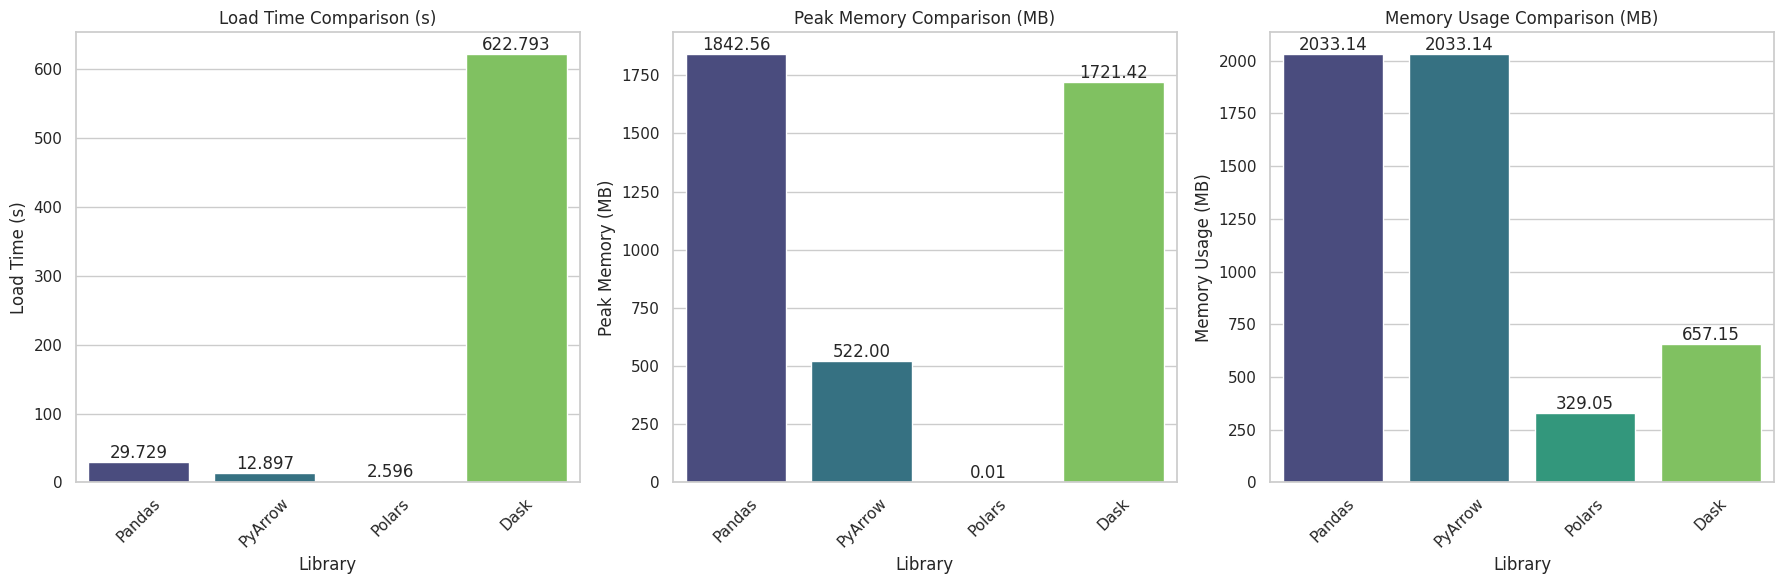

In [32]:
visualisation(libraries_df, 'Library')

According to the results, Polars yields the best performance overall.  

### Interpretation for execution time
- **Polars** is faster because it uses a Rust-based CSV reader with multithreading. This reduces overhead and speeds up data loading.  
- **PyArrow** is a close competitor as it is designed around the Apache Arrow memory format.  
- **pandas** is slower because it is largely single-threaded during parsing and relies on Python objects, which increases overhead and slows down processing.  
- **Dask**, on the other hand, does not make single CSV read faster as it splits the file into chunks and reads them in parallel. This only becomes beneficial when the dataset is very large or distributed across multiple files. For a single CSV, it can even introduce overhead due to task scheduling.

### Interpretation for memory usage
- **Polars** and **PyArrow** are both memory-efficient as they use the Apache Arrow columnar memory format, which is compact and avoids unnecessary Python object overhead.  
- **Dask** performs poorly because it is designed for parallel and distributed computation. For a single CSV, scheduling overhead dominates performance. However, it can reduce memory usage compared to pandas by processing data in chunks.  
- **pandas** stores data in NumPy arrays and Python objects, which introduces significant memory overhead, especially for large datasets and string-heavy columns.

### Interpretation for Processing Efficiency
- In terms of limitations and errors, all the parallel processing method encounter errors in loading the `features` and `lyrics` columns. PyArrow and Polars are uses a strict CSV parser which raise errors when the dataset has issues in the column. These issues are not experienced when using pandas.
- To ensure smooth execution, the `features` and `lyrics` columns are cleaned and formatted before benchmarking.
- In terms of ease of implementation, all the libraries are implemented similarly, where a function is being called to read the csv file.
- In terms of scalability, the parallel processing libraries are more scalable. In terms of flexibility, pandas is more flexible.

## Task 5: Conclusion
Depending on the need of the analysis, different combination of strategy can be implemented. There is no one size fit all solution, some strategy are more suitable than the others for certain situation.

While for chosing a libraries, the quality of the raw data and the characteristic of the dataset have to be inspected. For example Polars and PyArrow are more strict while the Dask is suitable for distributed data.